In [1]:
# imports
import pandas as pd
import matplotlib as plt
import math

# display options
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [2]:
years = [
    2011,
    2012,
    2013,
    2014,
    2015,
    2016,
    2017,
    2018,
    2019,
    2020,
    2021,
    2022,
    2023,
    2024,
    2025,
    2026,
]

In [3]:
# helper functions
def billions_formatter(x, pos):
    return f"{x * 1e-9:,.1f}B"

def getAnnualBudget(df, year):
    return df[df["year"] == year]["amount"].sum()

def getAnnualFundType(df, year, fundType):
    return df[(df["year"] == year) & (df["fund_type"] == fundType)]["amount"].sum()

def getAnnualGrantFunds(df, year):
    return getAnnualFundType(df, year, "GRANTS") + getAnnualFundType(df, year, "CDBG")

def getAnnualLocalFunds(df, year):
    return getAnnualFundType(df, year, "LOCAL")

In [4]:

def plotBudget(df, title):
    budgets = pd.DataFrame(
        {
            "year": years,
            "local": list(map(lambda x: int(getAnnualLocalFunds(df, x)), years)),
            "grants": list(map(lambda x: int(getAnnualGrantFunds(df, x)), years)),
        }
    )
    budgets = budgets.set_index("year")
    ax = budgets.plot.area()
    ax.yaxis.set_major_formatter(plt.ticker.FuncFormatter(billions_formatter))
    ax.set_title(f"{title} Budget")
    ax.plot()

In [5]:
df = pd.read_csv("data/ordinance.csv")
df.head()

,year,functional_category,department_number,appropriation_account,fund_type,fund_code,amount
0,2011,Finance & Administration,1,0005,LOCAL,0100,5892558.00
1,2011,Finance & Administration,1,0005,LOCAL,0355,384120.00
2,2011,Finance & Administration,1,0030,LOCAL,0100,-519910.00
3,2011,Finance & Administration,1,0030,LOCAL,0355,-36432.00
4,2011,Finance & Administration,1,0126,LOCAL,0100,1310.00


In [6]:
years = df["year"].unique()
functionalCategories = df["functional_category"].unique()

In [7]:
pd.DataFrame(
    {
        "year": years,
        "total": list(map(lambda x: int(getAnnualBudget(df, x)), years)),
    }
).set_index("year")

,total
year,
2011,8700334637
2012,8614865000
2013,8745336000
2014,9114711000
2015,9555106000
2016,10056354000
2017,10677480000
2018,10752004000
2019,11400085000


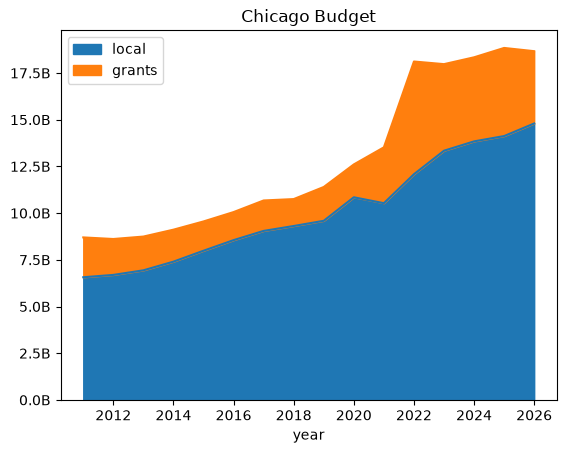

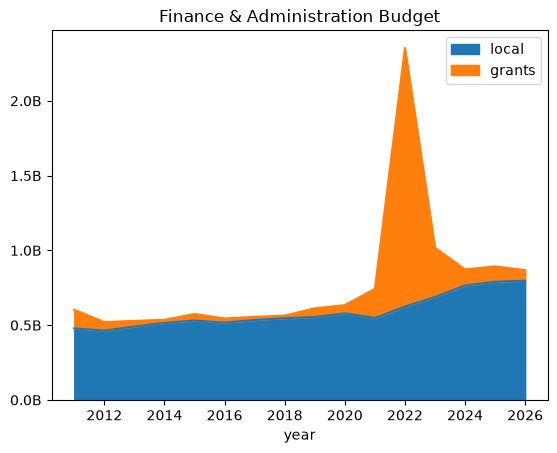

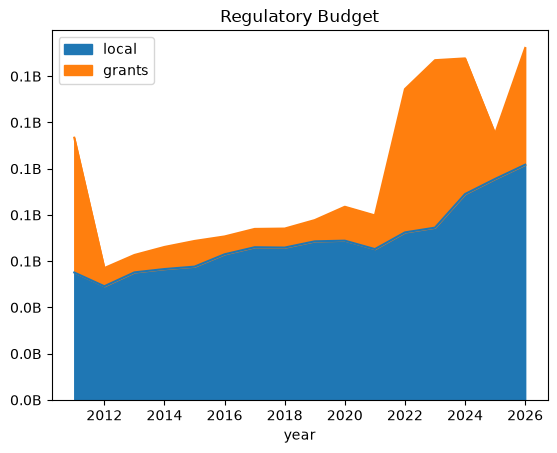

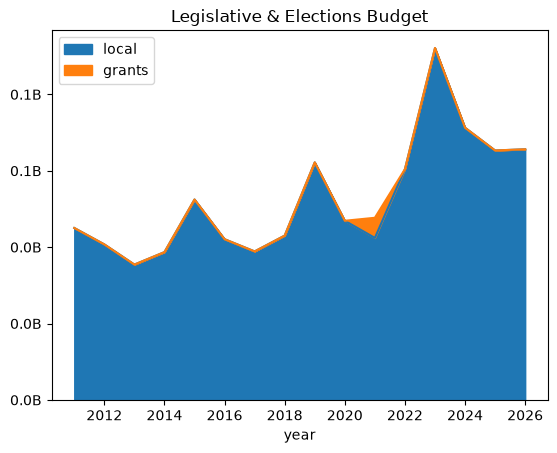

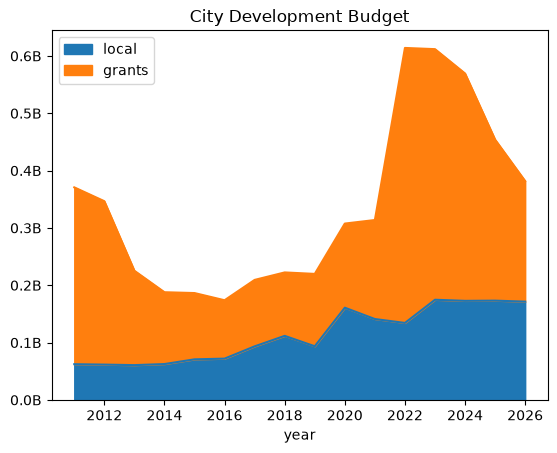

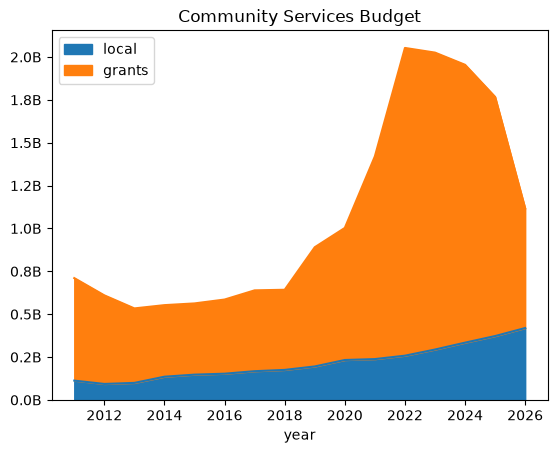

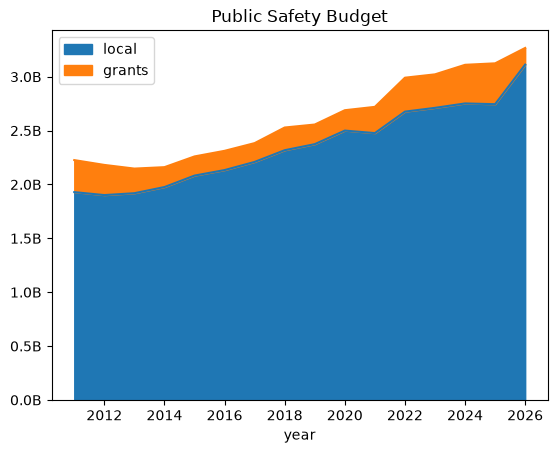

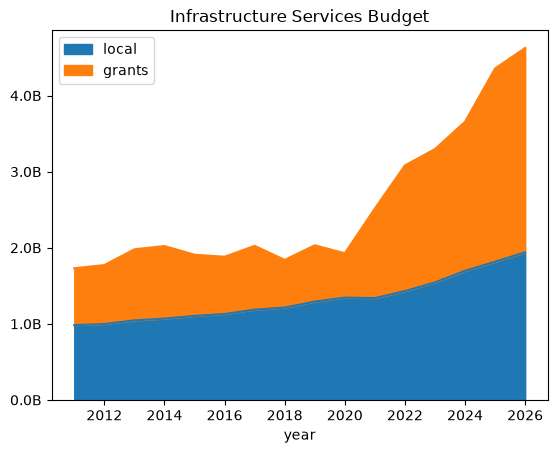

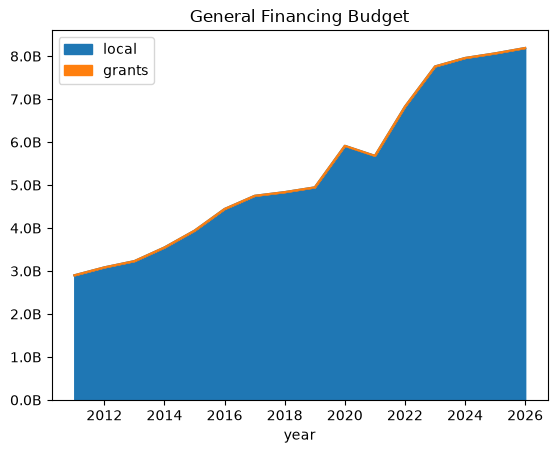

In [8]:
plotBudget(df, "Chicago")

for category in functionalCategories.unique():
    plotBudget(df[df["functional_category"] == category], category)

In [9]:
df[df["year"] == 2026].reset_index(drop=True).head(10)

,year,functional_category,department_number,appropriation_account,fund_type,fund_code,amount
0,2026,Finance & Administration,1,0005,GRANTS,925L,95867.00
1,2026,Finance & Administration,1,0005,GRANTS,925L,172505.00
2,2026,Finance & Administration,1,0005,GRANTS,GA00,106529.00
3,2026,Finance & Administration,1,0005,LOCAL,0100,10707977.00
4,2026,Finance & Administration,1,0005,LOCAL,0355,470873.00
5,2026,Finance & Administration,1,0005,LOCAL,0B21,124909.00
6,2026,Finance & Administration,1,0005,LOCAL,0B70,806222.00
7,2026,Finance & Administration,1,0006,GRANTS,925L,45827.00
8,2026,Finance & Administration,1,0006,GRANTS,GA00,1013.00
9,2026,Finance & Administration,1,0039,LOCAL,0100,57490.00
